In [ ]:
import pandas as pd
import seaborn as sns
from google.colab import drive
import matplotlib.pyplot as plt
import plotly.express as px


## Kaggle datasets

In this notebook we are going to discuss the collection of dataset available on the kaggle platform.

The data is published under the CC0 license on [this kaggle page](https://www.kaggle.com/canggih/voted-kaggle-dataset)

### Dataset contents

The dataset contains information on:
*   **Title** - name of the dataset,
*   **Data Type** - format that the data is published in,
*   **License** - type of license regulating the use of the set,
*   **Votes** - number of votes for the set,
*   **Views** - number of views of the set,
*   **Downloads** - number of downloads of the set,
*   **Kernels** - number of kernels based on the set,
*   **Topics** - number of topics.







The necessary data is provided with the document: the code below imports the file.

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
kaggle = pd.read_csv('/content/drive/My Drive/Vis/Kaggle Datasets/kaggle-ds.csv')
kaggle

,Title,Data Type,License,Votes,Views,Downloads,Kernels,Topics
0,Credit Card Fraud Detection,CSV,ODbL,1241,442136.0,53128.0,1782.0,26.0
1,European Soccer Database,SQLite,ODbL,1046,396214.0,46367.0,1459.0,75.0
2,TMDB 5000 Movie Dataset,CSV,Other,1024,446255.0,62002.0,1394.0,46.0
3,Global Terrorism Database,CSV,Other,789,187877.0,26309.0,608.0,11.0
4,Bitcoin Historical Data,CSV,CC4,618,146734.0,16868.0,68.0,13.0
...,...,...,...,...,...,...,...,...
2145,Fortnite: Battle Royale Chest Location Coordin...,CSV,Other,2,369.0,16.0,NaN,0.0
2146,Titanic: Passenger Nationalities,CSV,Other,2,75.0,10.0,NaN,0.0
2147,Stemmed and Lementized English words,{}JSON,ODbL,2,70.0,11.0,NaN,0.0
2148,Los Angeles Weather During 2014,CSV,CC0,2,78.0,5.0,NaN,0.0


## Notebook preparation

We want to start by making sure that the data has been correctly identified and make necessary conversions.

Based on data overview, we expect the first column to contain text-based information that makes it possible to tell the different datasets apart. We also expect that **Data Type** and **License** columns store text-based information about categories.

We assume that the remaining columns are numeric. Let's check the actual data in the set.

### Checking data types

In [ ]:
kaggle.dtypes

,0
Title,object
Data Type,object
License,object
Votes,int64
Views,float64
Downloads,float64
Kernels,float64
Topics,float64


We need to verify if the data has records where any of the columns is missing information.

In [ ]:
"complete records: " + str(len(kaggle.dropna(how="any"))) + "; total records: " + str(len(kaggle))

'complete records: 845; total records: 2150'

## Dataset type conversion

Let's look at the information on the data types in the **Data Type** column.

In [ ]:
kaggle["Data Type"].value_counts()

,count
Data Type,
CSV,1593
Other,468
{}JSON,56
SQLite,25
BigQuery,8


In this case we can only identify the data type as a categorical one.

In [ ]:
kaggle["Data Type"] = kaggle["Data Type"].astype("category")

### Converting licenses to categories

Next, let's see what types of licenses are in the **License** column.

In [ ]:
kaggle["License"].value_counts()

,count
License,
CC0,845
Other,751
CC4,324
ODbL,181
GPL,26
CC3,23


Here, it is also enough if the data is identified as a category.

In [ ]:
kaggle["License"] = kaggle["License"].astype("category")

### Numeric variables analysis

Let's spend a moment reviewing the basic statistics for numeric variables

In [ ]:
kaggle.describe()

,Votes,Views,Downloads,Kernels,Topics
count,2150.000000,2145.000000,2135.000000,1206.000000,1558.000000
mean,24.011628,7299.300699,923.793443,38.392206,1.261874
std,64.788465,22660.139843,3098.584600,147.499168,3.589140
min,2.000000,29.000000,0.000000,2.000000,0.000000
25%,4.000000,750.000000,60.000000,3.000000,0.000000
50%,8.000000,1930.000000,187.000000,7.000000,0.000000
75%,19.000000,5151.000000,602.000000,21.000000,2.000000
max,1241.000000,446255.000000,62002.000000,3394.000000,75.000000


Note that in all cases we can see that maximum values are many times higher that the mean ones; and that for all statistics except  **Topics**, standard deviation is multiple times higher than the mean.
We expect to see significant outliers in this collection of datasets.

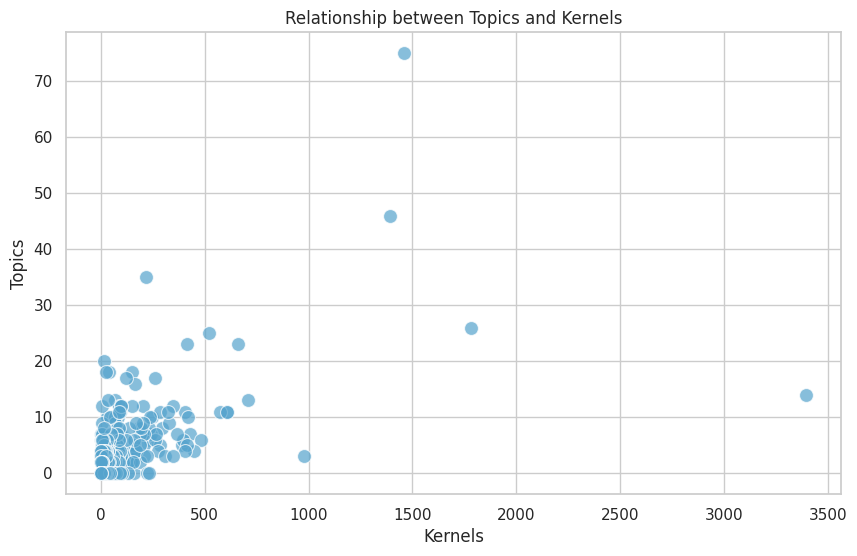

In [ ]:
#Using the kaggle dataset dataframe, create a chart showing the relationship between topics and kernels. Use color to distinguish the datasets based on the type of data.
sns.set_theme(style='whitegrid', palette = 'icefire')

plt.figure(figsize=(10,6))
sns.scatterplot(data=kaggle.reset_index(), x='Kernels', y='Topics', s=100, alpha=0.7)
plt.title('Relationship between Topics and Kernels')
plt.xlabel('Kernels')
plt.ylabel('Topics')
plt.grid(True)
plt.show()



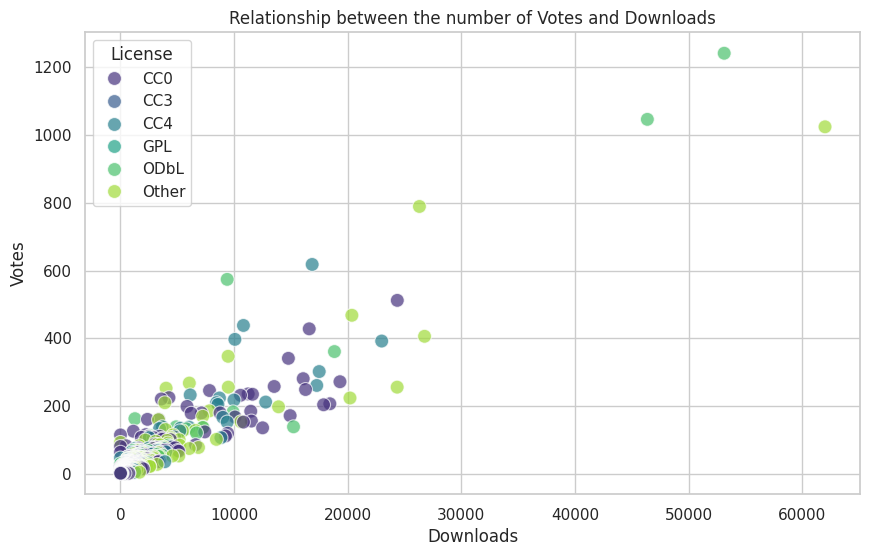

In [ ]:
sns.set_theme(style='whitegrid', palette = 'viridis')

plt.figure(figsize=(10,6))
sns.scatterplot(data=kaggle.reset_index(), x='Downloads', y='Votes', hue='License', s=100, alpha=0.7)
plt.title('Relationship between the number of Votes and Downloads')
plt.xlabel('Downloads')
plt.ylabel('Votes')
plt.grid(True)
plt.show()



In this case, we will use a dataset about the kaggle platform to visualize the distributions of categorical data.

 create plots that count the number of occurrences of each category of dataset.

/tmp/ipykernel_708/1381362269.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=kaggle, x='Data Type', palette='viridis')


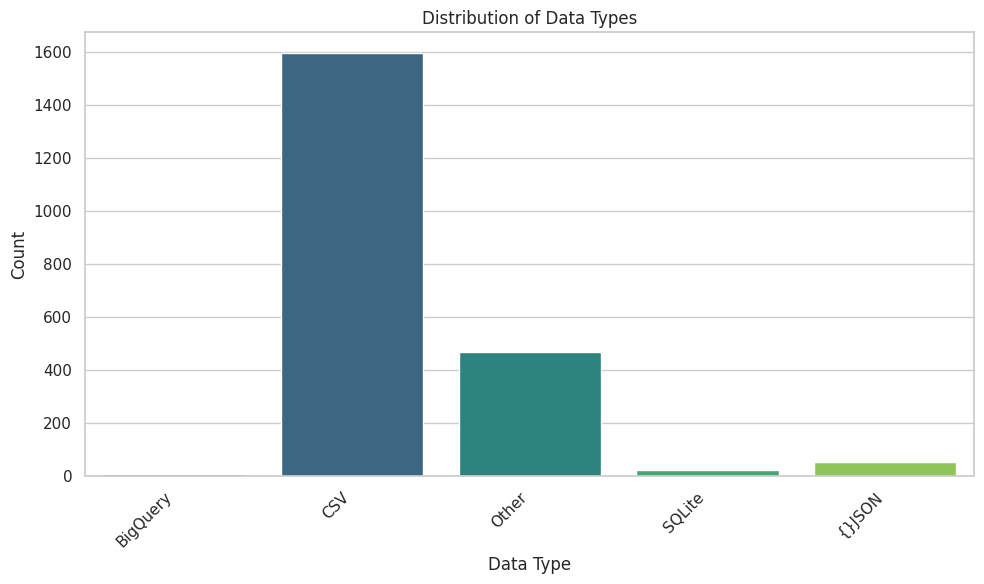

/tmp/ipykernel_708/1381362269.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=kaggle, x='License', palette='plasma')


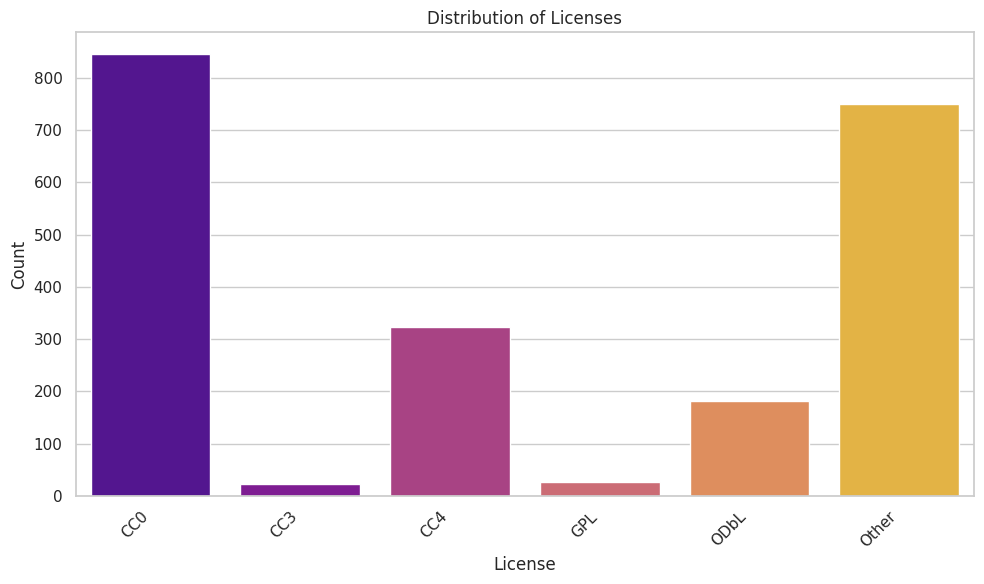

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot for Data Type distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=kaggle, x='Data Type', palette='viridis')
plt.title('Distribution of Data Types')
plt.xlabel('Data Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot for License distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=kaggle, x='License', palette='plasma')
plt.title('Distribution of Licenses')
plt.xlabel('License')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Feature distributions for categories-kaggle

In this case, we will use a dataset about the kaggle platform to visualize the distributions of numeric features in this dataset divided by category.

1. For the Data Type category, create plots that illustrate the distributions of numerical features using the default plot type and a bar version. To avoid duplicating code you can define a function called for example: plot_catplot, that generates a catplot chart in the default and bar variants. The function can take arguments:

the object where the dataframe is stored,

column name on the X axis (Data Type in our case)

column name on the Y axis Then you can call the function in a loop, iterating over the list of numeric features in the dataset (you must define the list earlier).

2. Based on the results of this and the previous exercise, what can you say about BigQuery type sets? What conclusions do you have based on scatter plots; what conclusions do you have based on bar charts?


--- Plotting for Votes by Data Type ---


/tmp/ipykernel_708/3969482282.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x=x_col, y=y_col, aspect=2, height=6, palette='viridis')


<Figure size 1200x600 with 0 Axes>

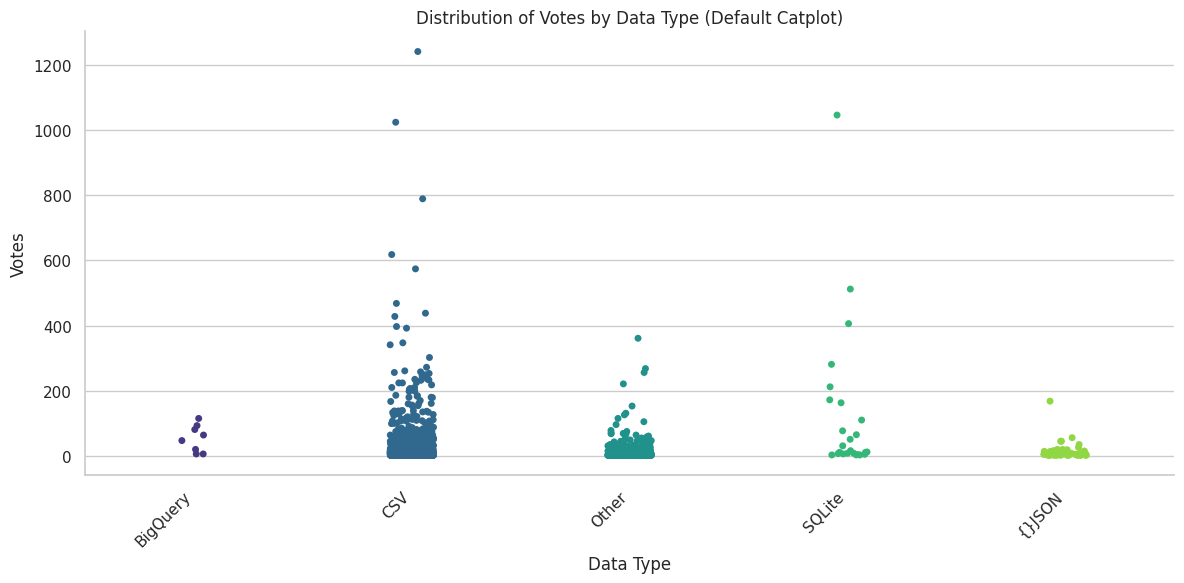

/tmp/ipykernel_708/3969482282.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x=x_col, y=y_col, kind='bar', aspect=2, height=6, palette='plasma')


<Figure size 1200x600 with 0 Axes>

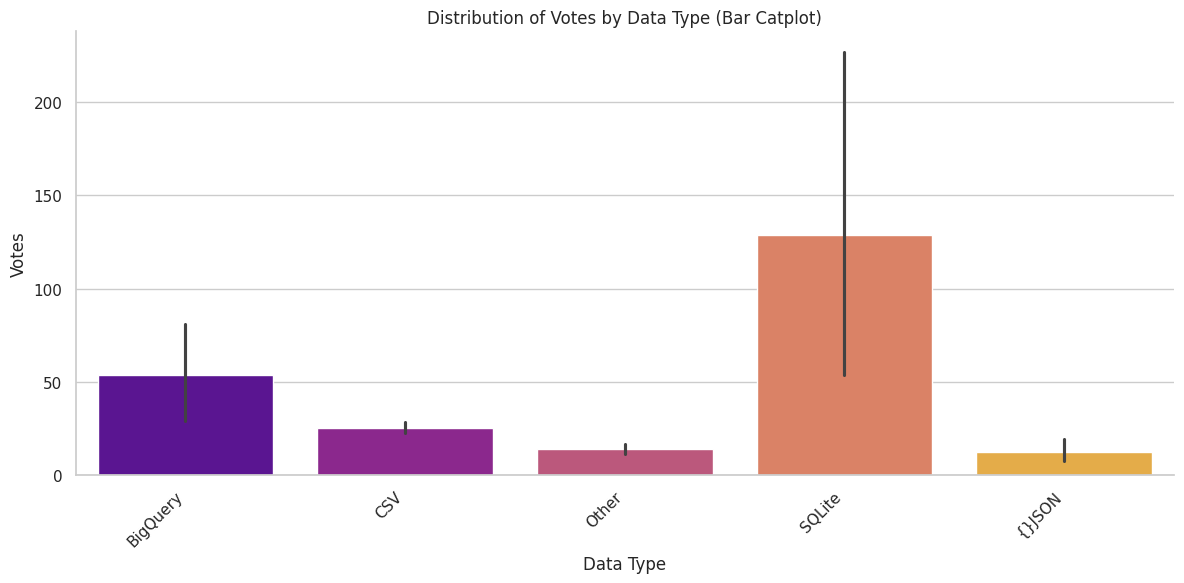


--- Plotting for Views by Data Type ---


/tmp/ipykernel_708/3969482282.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x=x_col, y=y_col, aspect=2, height=6, palette='viridis')


<Figure size 1200x600 with 0 Axes>

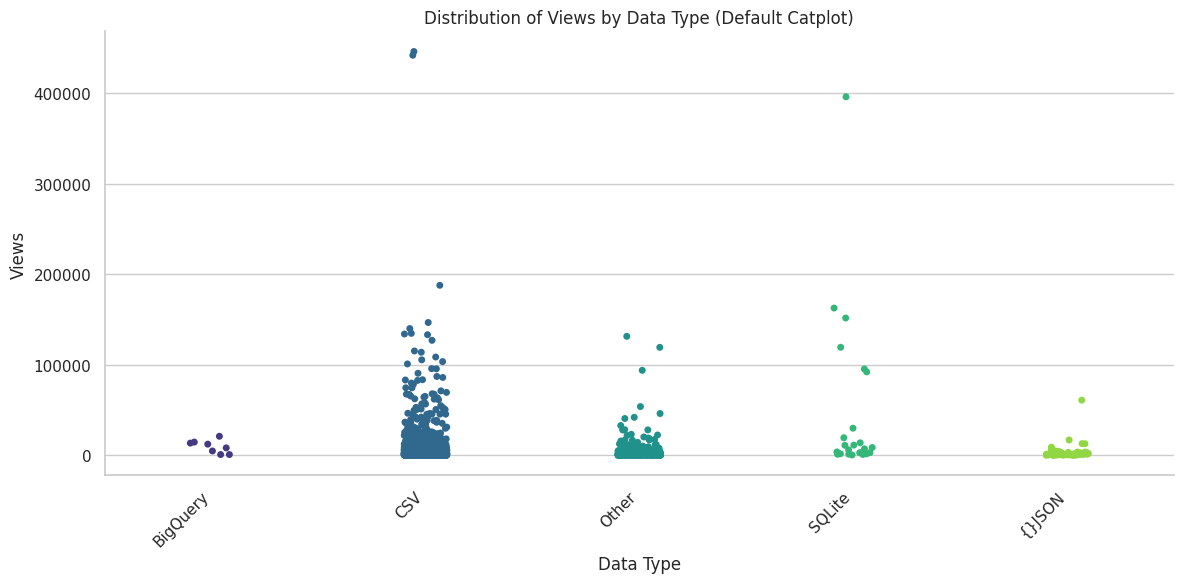

/tmp/ipykernel_708/3969482282.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x=x_col, y=y_col, kind='bar', aspect=2, height=6, palette='plasma')


<Figure size 1200x600 with 0 Axes>

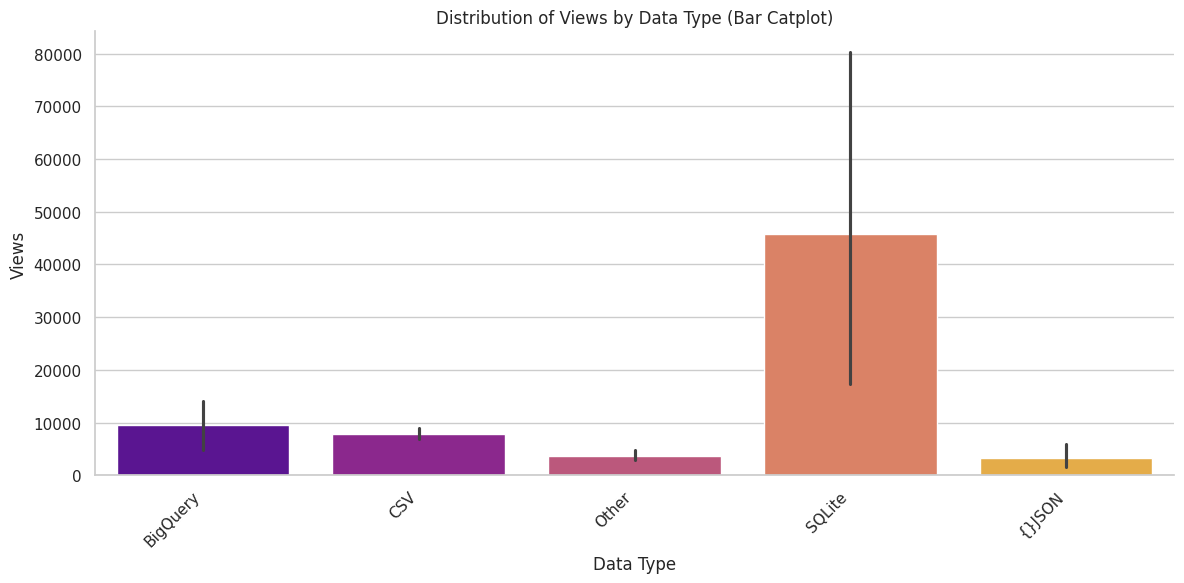


--- Plotting for Downloads by Data Type ---


/tmp/ipykernel_708/3969482282.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x=x_col, y=y_col, aspect=2, height=6, palette='viridis')


<Figure size 1200x600 with 0 Axes>

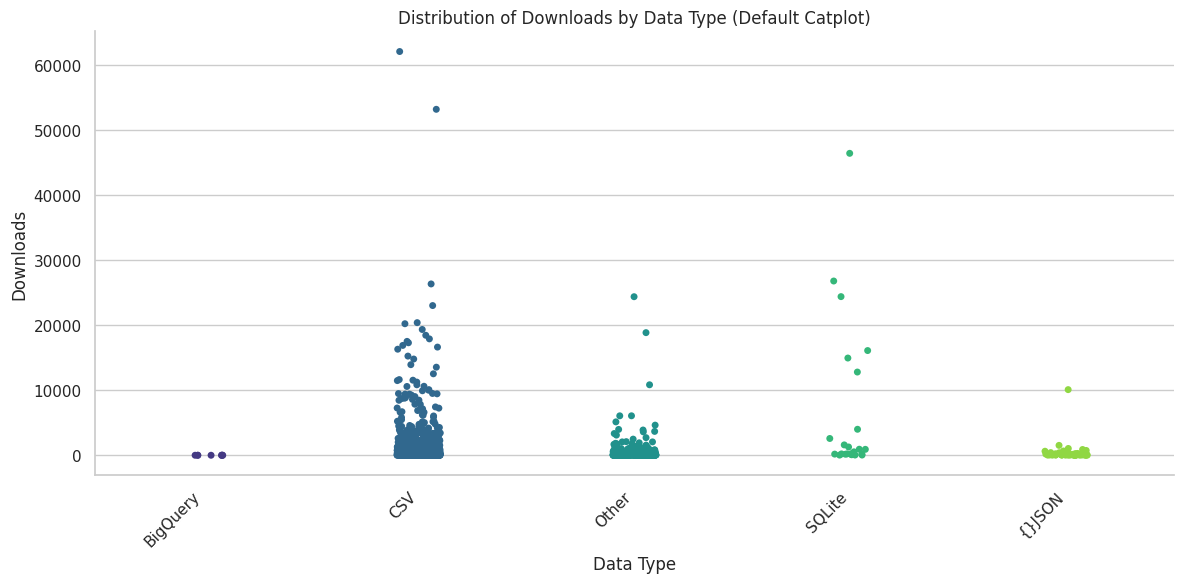

/tmp/ipykernel_708/3969482282.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x=x_col, y=y_col, kind='bar', aspect=2, height=6, palette='plasma')


<Figure size 1200x600 with 0 Axes>

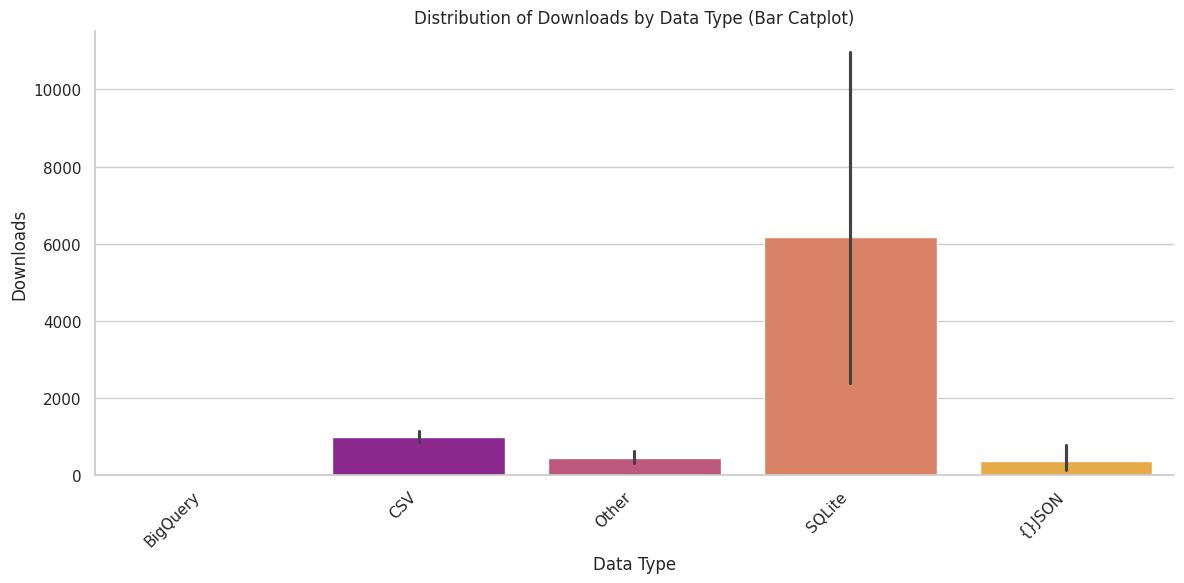


--- Plotting for Kernels by Data Type ---


/tmp/ipykernel_708/3969482282.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x=x_col, y=y_col, aspect=2, height=6, palette='viridis')


<Figure size 1200x600 with 0 Axes>

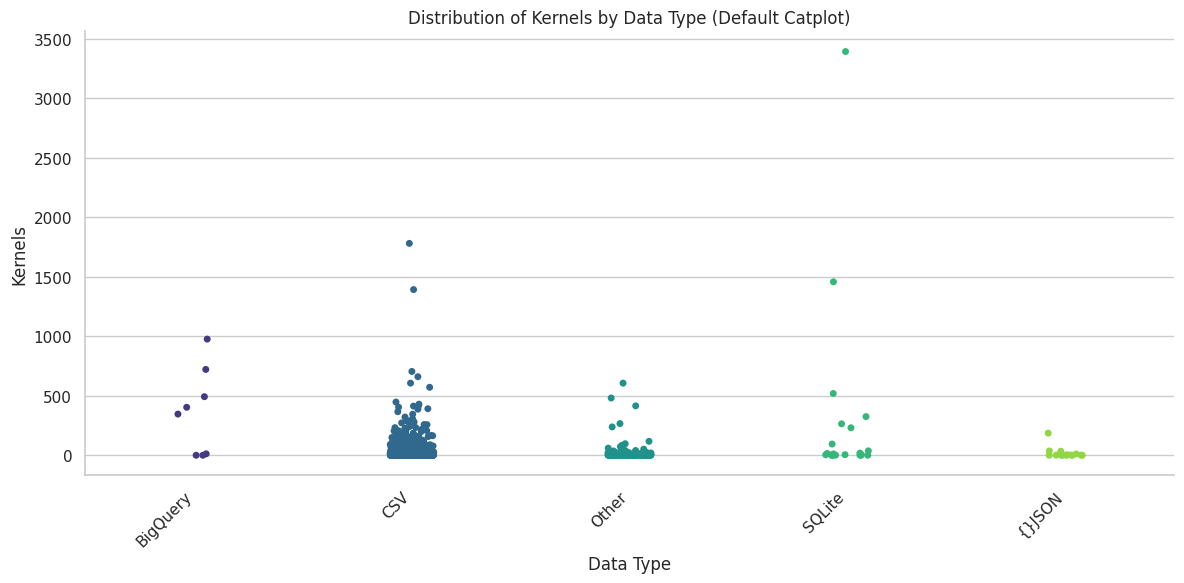

/tmp/ipykernel_708/3969482282.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x=x_col, y=y_col, kind='bar', aspect=2, height=6, palette='plasma')


<Figure size 1200x600 with 0 Axes>

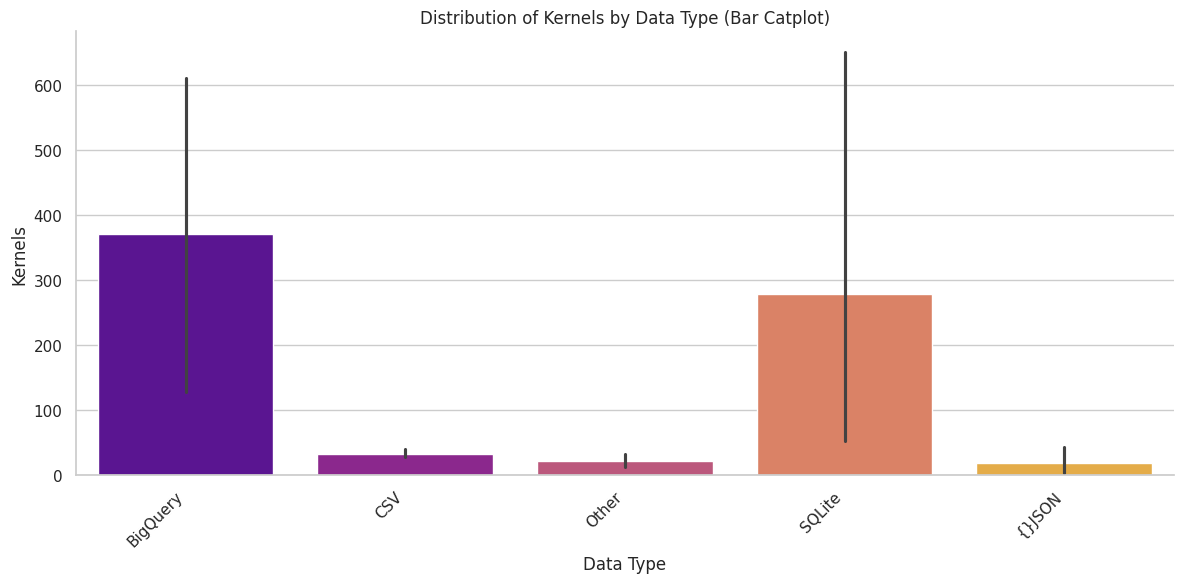


--- Plotting for Topics by Data Type ---


/tmp/ipykernel_708/3969482282.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x=x_col, y=y_col, aspect=2, height=6, palette='viridis')


<Figure size 1200x600 with 0 Axes>

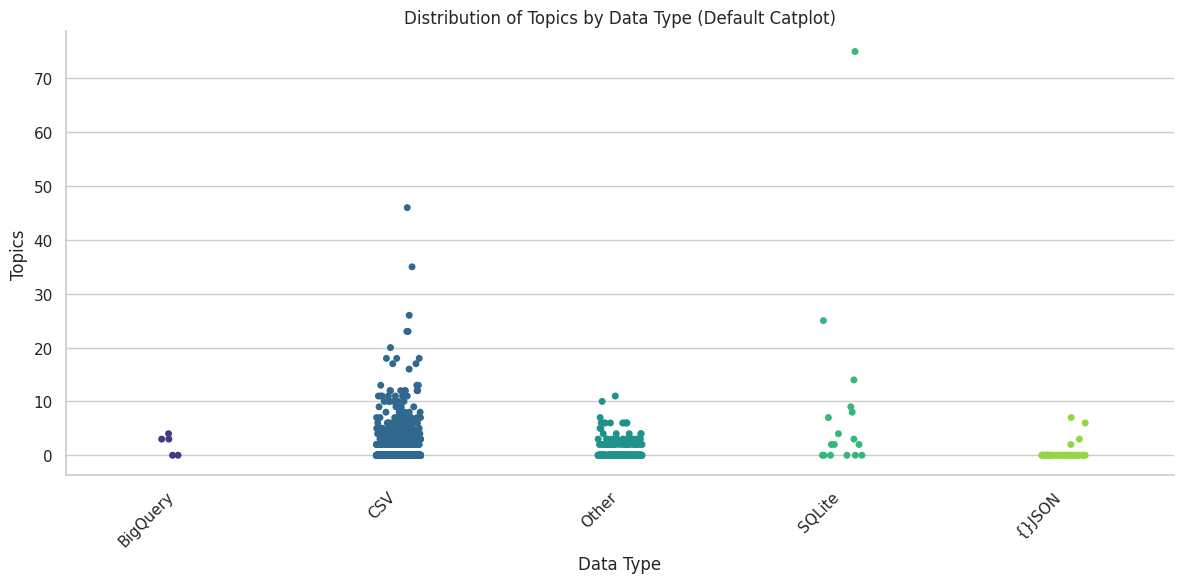

/tmp/ipykernel_708/3969482282.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x=x_col, y=y_col, kind='bar', aspect=2, height=6, palette='plasma')


<Figure size 1200x600 with 0 Axes>

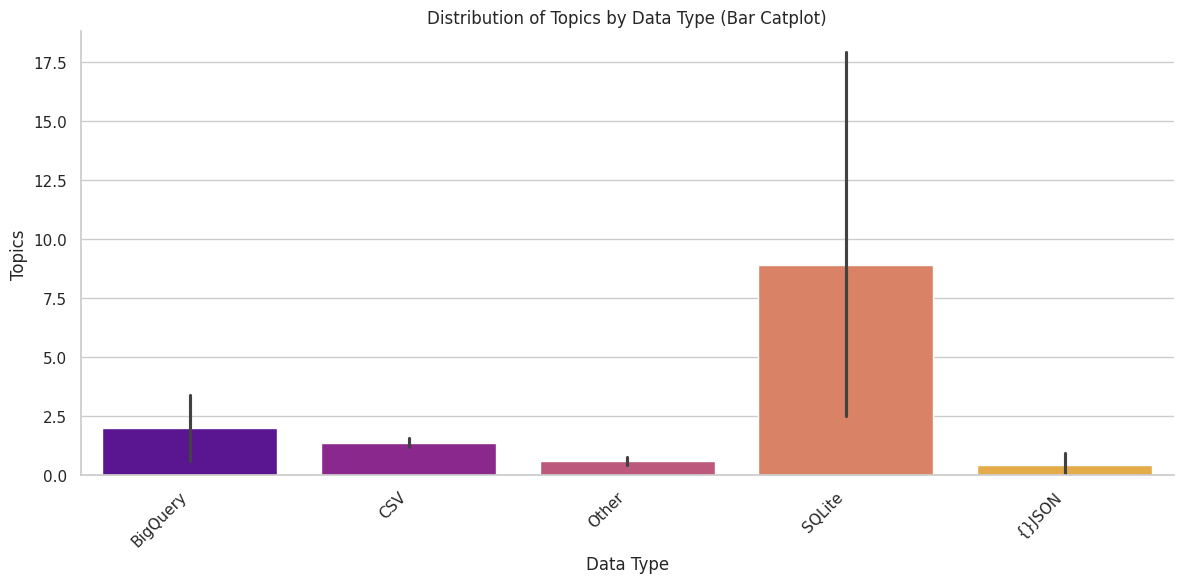

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_catplot(df, x_col, y_col):
    """
    Generates default (strip/swarm) and bar catplots for a given DataFrame,
    x-axis column, and y-axis column.
    """
    print(f"\n--- Plotting for {y_col} by {x_col} ---")


    plt.figure(figsize=(12, 6))
    sns.catplot(data=df, x=x_col, y=y_col, aspect=2, height=6, palette='viridis')
    plt.title(f'Distribution of {y_col} by {x_col} (Default Catplot)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.catplot(data=df, x=x_col, y=y_col, kind='bar', aspect=2, height=6, palette='plasma')
    plt.title(f'Distribution of {y_col} by {x_col} (Bar Catplot)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

numeric_features = kaggle.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude 'Votes', 'Views', 'Downloads', 'Kernels', 'Topics' if they were already plotted, or if we want to focus on others.

x_category = 'Data Type'

for feature in numeric_features:
    if feature != x_category: # Ensure not to plot Data Type against itself
        plot_catplot(kaggle, x_category, feature)

In [ ]:
fig = px.scatter(
    data_frame=kaggle, x="Downloads", y= "Views", color = "Views", size="Votes", color_continuous_scale=["red", "pink", "purple"])
fig.update_traces(marker_line_width=1, marker_line_color="#FFC482")
fig.show()


In [ ]:
fig = px.scatter(data_frame=kaggle,
                 x="Downloads",
                 y="Views",
                 size="Votes",
                 color="License",
                 size_max=50,
                 title="Relationship between Downloads, Views, and Votes by License")
fig.show()

In [ ]:
fig = px.scatter(data_frame=kaggle,
                 x="Views",
                 y="Topics",
                 size="Votes",
                 color="Data Type",
                 size_max=40,
                 hover_data=["Data Type"],
                 title="Relationship between Views, Topics, and Votes by Data Type")
fig.show()

In [ ]:
fig = px.scatter(
  data_frame=kaggle,
  x="Downloads",
  y="Views",
  color="Views",
  size="Votes",
  color_continuous_scale=["red", "pink", "purple"],
)
fig.update_traces(
  marker_line_width=1,
  marker_line_color="blue"
)
fig.show()

In [ ]:
fig = px.scatter(
    data_frame=kaggle,
    x="Kernels",
    y="Topics",
    facet_col="License",
    facet_col_wrap=3,
    size="Votes",
    color="Data Type"
)
fig.show()